Import dataset and libraries

In [13]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s6e8')

print("Path to competition files:", path)

Path to competition files: /root/.cache/kagglehub/competitions/playground-series-s6e8


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix


Loading dataset and preliminary EDA


In [15]:
train = pd.read_csv('/root/.cache/kagglehub/competitions/playground-series-s6e8/train.csv')
train.drop('id', axis = 1, inplace = True)
train.head()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


In [16]:
test = pd.read_csv('/root/.cache/kagglehub/competitions/playground-series-s6e8/test.csv')
test_ids = test['id']
test.drop('id', axis = 1, inplace = True)
test.head()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,30.0,9.34,NaN,0.77,4.09,7.15,153.0,16.0,NaN,Other,Medium,Yes
1,NaN,NaN,1.91,NaN,1.20,8.67,239.0,148.0,10.68,Female,High,No
2,26.0,8.48,3.64,NaN,3.39,7.47,106.0,123.0,NaN,Male,NaN,No
3,20.0,8.37,2.99,1.69,2.53,5.45,178.0,55.0,9.88,Male,High,Yes
4,25.0,8.25,4.02,1.21,2.32,8.46,63.0,86.0,10.72,Male,Low,No


In [17]:
train.shape

(691369, 13)

In [18]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   age                      662440 non-null  float64
 1   daily_screen_time_hours  595515 non-null  float64
 2   social_media_hours       557374 non-null  float64
 3   gaming_hours             564548 non-null  float64
 4   work_study_hours         639851 non-null  float64
 5   sleep_hours              646889 non-null  float64
 6   notifications_per_day    623785 non-null  float64
 7   app_opens_per_day        610659 non-null  float64
 8   weekend_screen_time      579306 non-null  float64
 9   gender                   662335 non-null  object 
 10  stress_level             636221 non-null  object 
 11  academic_work_impact     647145 non-null  object 
 12  addicted_label           691369 non-null  int64  
dtypes: float64(9), int64(1), object(3)
memory usage: 68.6+ MB


Data type conversion

In [19]:
train.age = train.age.astype('Int64', errors = 'ignore')
train.notifications_per_day = train.notifications_per_day.astype('Int64', errors = 'ignore')
train.app_opens_per_day = train.app_opens_per_day.astype('Int64', errors = 'ignore')
train.gender = train.gender.astype('category', errors = 'ignore')
train.stress_level = train.stress_level.astype('category', errors = 'ignore')
train.academic_work_impact = train.academic_work_impact.astype('category', errors = 'ignore')
train.addicted_label = train.addicted_label.astype('category', errors = 'ignore')

test.age = test.age.astype('Int64', errors = 'ignore')
test.notifications_per_day = test.notifications_per_day.astype('Int64', errors = 'ignore')
test.app_opens_per_day = test.app_opens_per_day.astype('Int64', errors = 'ignore')
test.gender = test.gender.astype('category', errors = 'ignore')
test.stress_level = test.stress_level.astype('category', errors = 'ignore')
test.academic_work_impact = test.academic_work_impact.astype('category', errors = 'ignore')

In [20]:
train.isna().sum()

,0
age,28929
daily_screen_time_hours,95854
social_media_hours,133995
gaming_hours,126821
work_study_hours,51518
sleep_hours,44480
notifications_per_day,67584
app_opens_per_day,80710
weekend_screen_time,112063
gender,29034


In [21]:
x_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

## Attempt to ascertain how to deal with NANs

Check for MAR (relationship between categories where there are missing values)

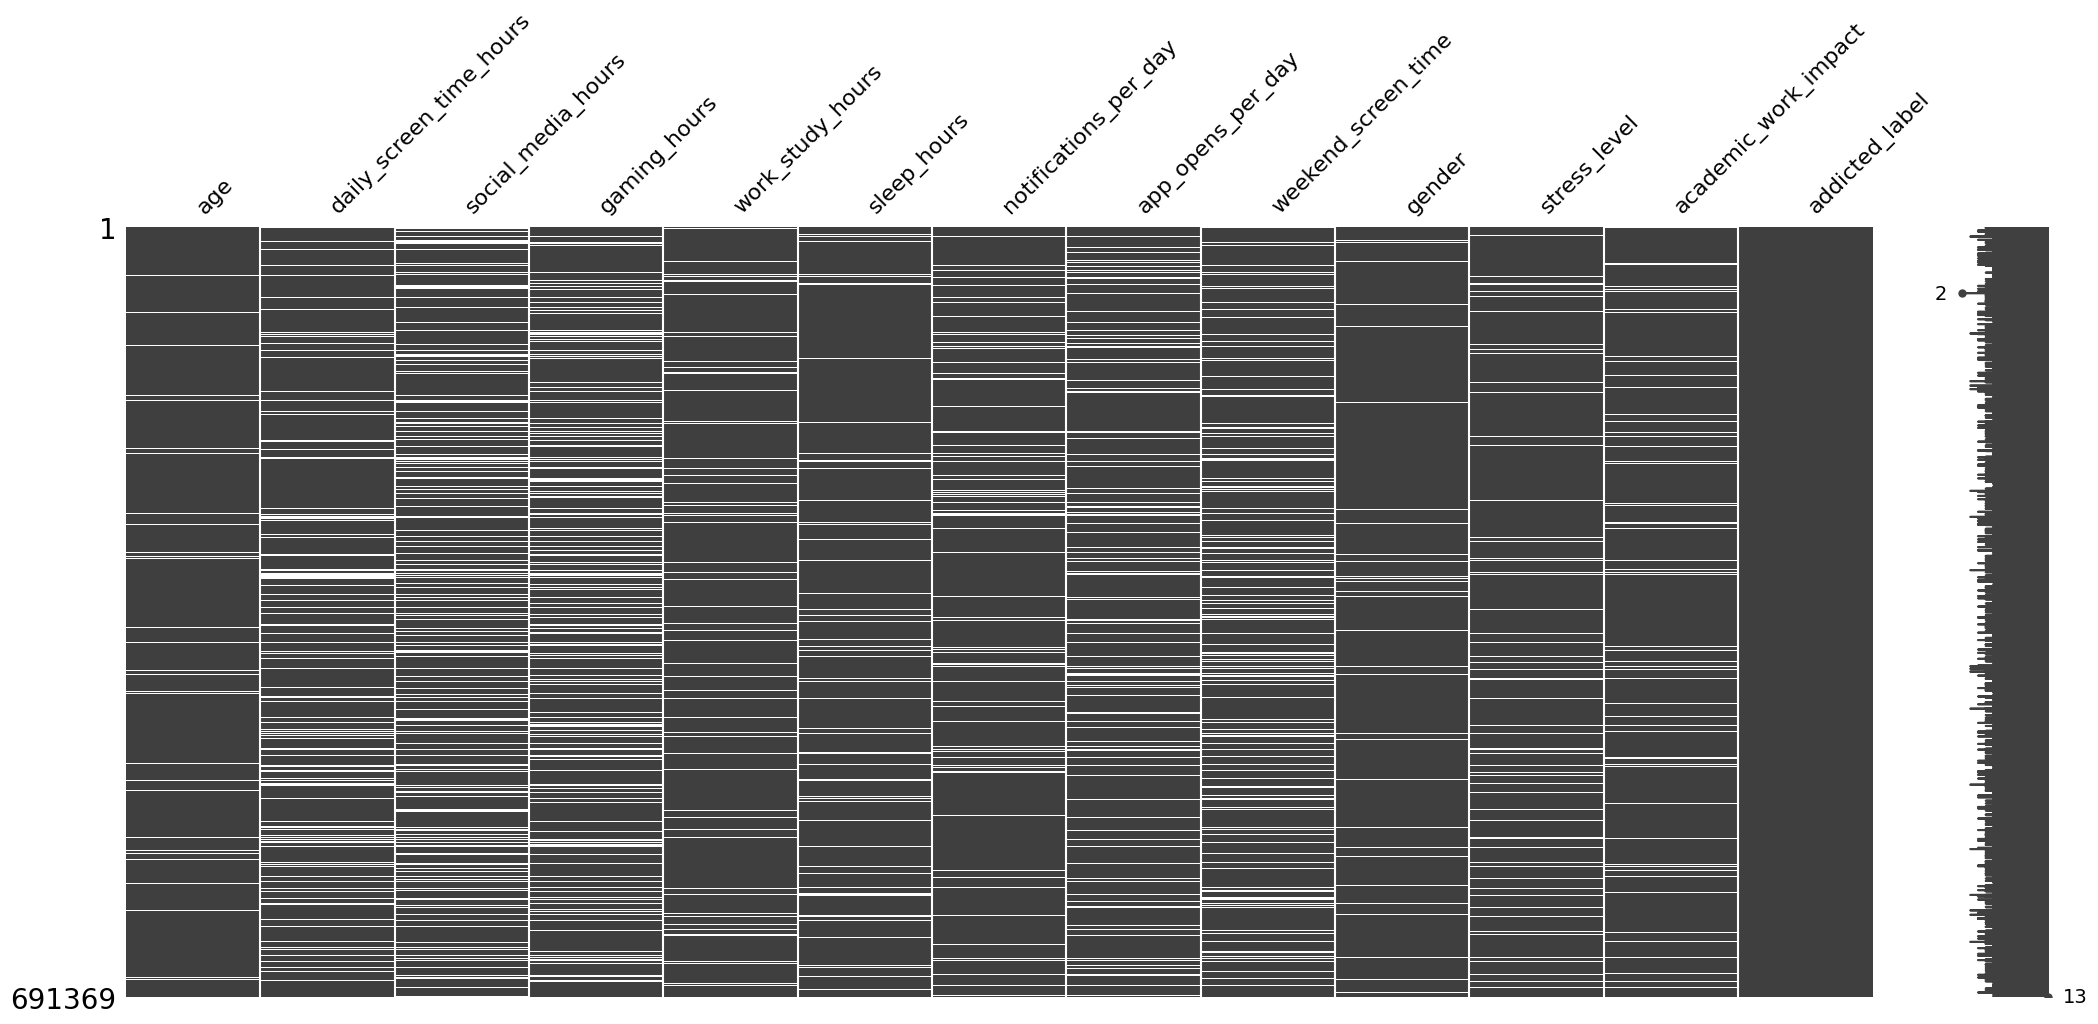

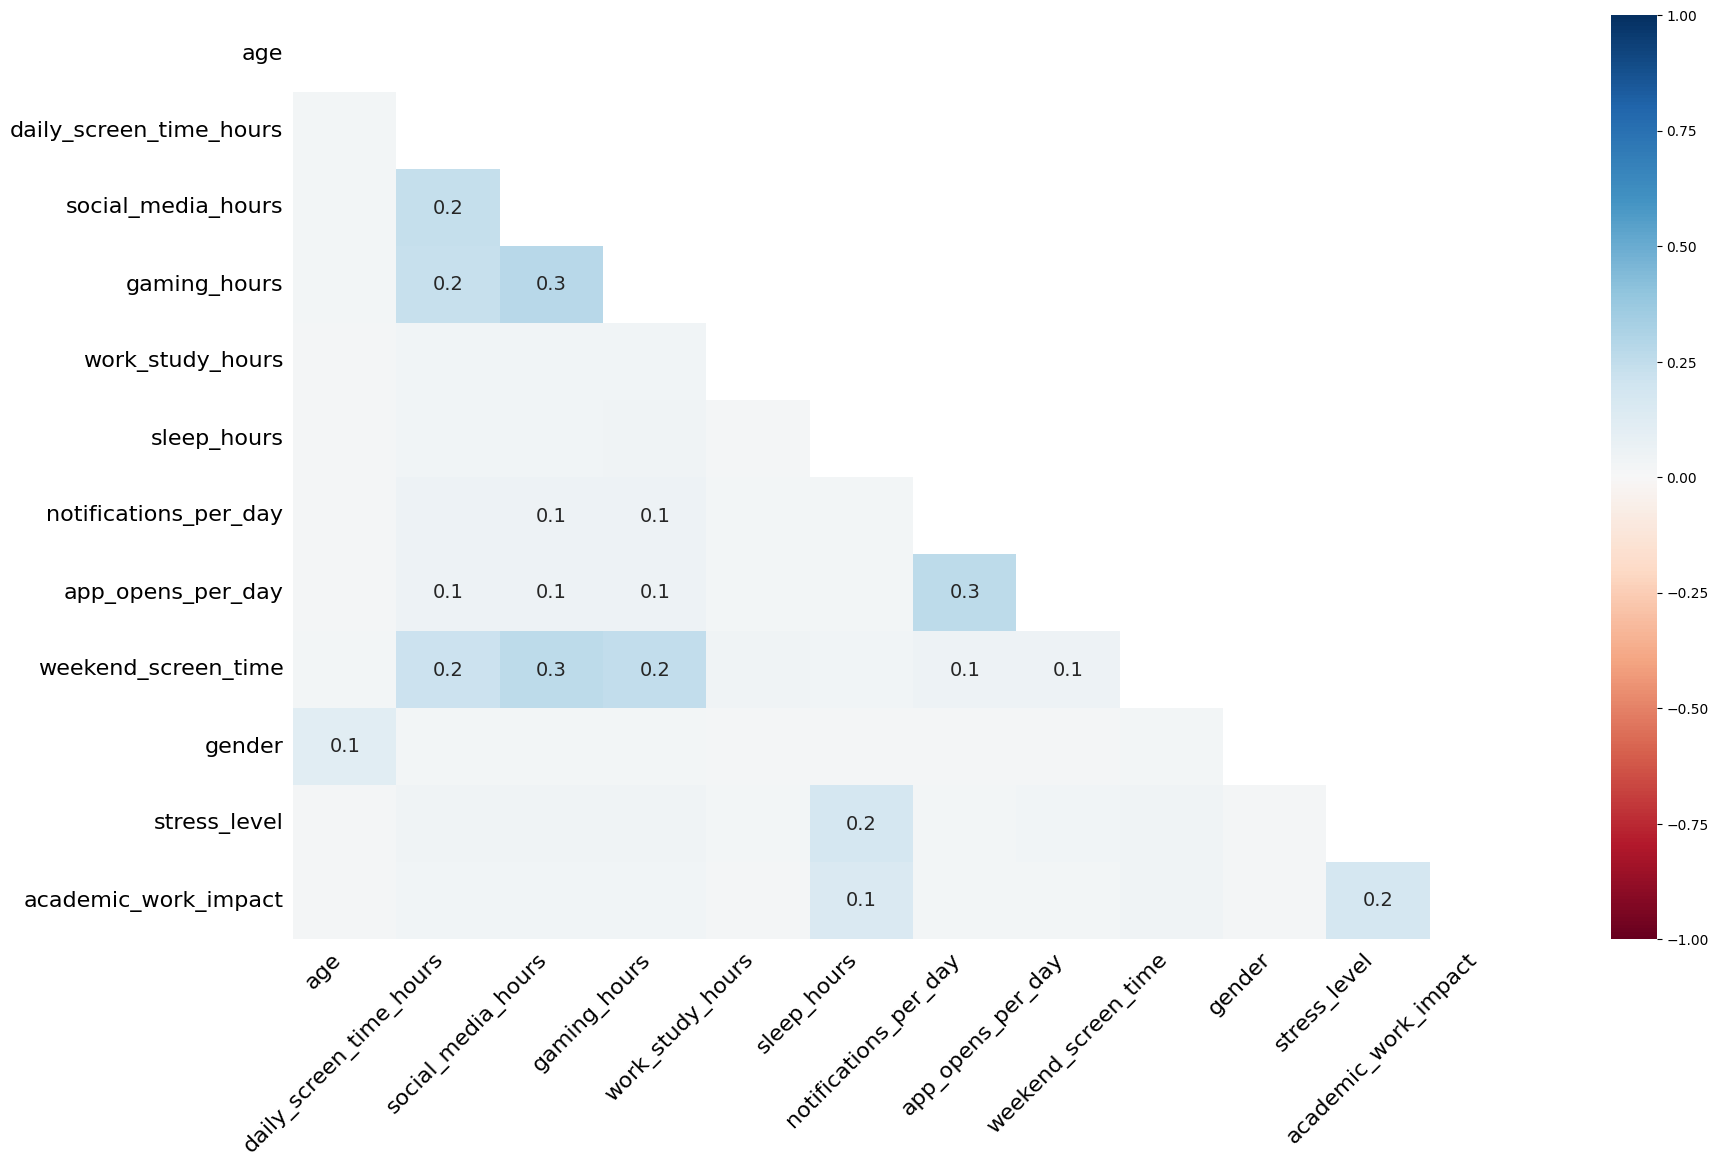

In [22]:
import missingno as msno
msno.matrix(train)
plt.show()

msno.heatmap(train)
plt.show()

Check for MCAR

In [23]:
!pip install -q pingouin
import pingouin as pg

def missing_test(df):
  results = []

  cols_with_missing = list(df.columns[df.isna().any()])

  for col_with_missing in cols_with_missing:
    categorical_missing = df[col_with_missing].isna().astype(int)

    other_cols = [col for col in df.columns if col != col_with_missing]

    for col in other_cols:
      temp = pd.DataFrame({
          'missing': categorical_missing,
          'other': df[col]
      }).dropna(axis = 0, subset = ['other'])

      if temp['missing'].nunique() < 2:
        continue

      try:
        if pd.api.types.is_numeric_dtype(df[col]):
          group_0 = temp.loc[temp['missing'] == 0, 'other']
          group_1 = temp.loc[temp['missing'] == 1, 'other']

          ttest_result = pg.ttest(group_0, group_1)
          results.append({
              'missing col': col_with_missing,
              'other': col,
              'test': 't-test',
              'p val': ttest_result['p_val'].values[0]
          })
        else:
          expected, observed, stats = pg.chi2_independence(
              data = temp,
              x = 'missing',
              y = 'other'
          )
          results.append({
              'missing col': col_with_missing,
              'other': col,
              'test': 'chisq-test',
              'p val': stats.loc[stats['test'] == 'pearson', 'pval'].values[0]
          })
      except Exception as e:
        print(f"{col_with_missing} vs {col}: {type(e).__name__}: {e}")
        results.append({
              'missing col': col_with_missing,
              'other': col,
              'test': 'failed',
              'p val': None
          })
  return pd.DataFrame(results)

results_df = missing_test(train)
results_df

,missing col,other,test,p val
0,age,daily_screen_time_hours,t-test,0.085661
1,age,social_media_hours,t-test,0.504280
2,age,gaming_hours,t-test,0.947909
3,age,work_study_hours,t-test,0.995367
4,age,sleep_hours,t-test,0.533443
...,...,...,...,...
139,academic_work_impact,app_opens_per_day,t-test,0.189540
140,academic_work_impact,weekend_screen_time,t-test,0.080890
141,academic_work_impact,gender,chisq-test,0.294720
142,academic_work_impact,stress_level,chisq-test,0.218873


In [24]:
from statsmodels.stats.multitest import multipletests
results_df['p adj'] = multipletests(results_df['p val'].dropna(), method = 'fdr_bh')[1]
results_df.loc[results_df['p adj'] < 0.05, :]

,missing col,other,test,p val,p adj
12,daily_screen_time_hours,age,t-test,1.205020e-95,4.338072e-94
24,social_media_hours,age,t-test,1.080035e-113,1.555250e-111
36,gaming_hours,age,t-test,1.043440e-112,7.512766e-111
48,work_study_hours,age,t-test,5.458679e-33,7.860498e-32
60,sleep_hours,age,t-test,9.431044e-35,1.508967e-33
61,sleep_hours,daily_screen_time_hours,t-test,6.437636e-04,7.725163e-03
72,notifications_per_day,age,t-test,6.343368e-65,1.522408e-63
73,notifications_per_day,daily_screen_time_hours,t-test,4.307907e-03,4.430990e-02
84,app_opens_per_day,age,t-test,3.642226e-68,1.048961e-66
96,weekend_screen_time,age,t-test,2.249062e-104,1.079550e-102


## Going with ML methods that automatically handle NANs

XGBoost

Early stopping

In [25]:
x_train_fit, x_validation, y_train_fit, y_validation = train_test_split(
    x_train, y_train, test_size = 0.10, random_state = 42, stratify = y_train
)

xgb_model = XGBClassifier(
    objective = 'binary:logistic',
    eval_metric = 'auc',
    enable_categorical = True,
    random_state = 42,
    n_estimators = 500,
    early_stopping_rounds = 20
)

xgb_model.fit(
    x_train, y_train,
    eval_set = [(x_validation, y_validation)],
    verbose = 10
)

print(xgb_model.best_iteration)

[0]	validation_0-auc:0.92689
[10]	validation_0-auc:0.93569
[20]	validation_0-auc:0.94351
[30]	validation_0-auc:0.95014
[40]	validation_0-auc:0.95355
[50]	validation_0-auc:0.95645
[60]	validation_0-auc:0.95875
[70]	validation_0-auc:0.96019
[80]	validation_0-auc:0.96150
[90]	validation_0-auc:0.96260
[100]	validation_0-auc:0.96347
[110]	validation_0-auc:0.96428
[120]	validation_0-auc:0.96519
[130]	validation_0-auc:0.96584
[140]	validation_0-auc:0.96651
[150]	validation_0-auc:0.96710
[160]	validation_0-auc:0.96775
[170]	validation_0-auc:0.96825
[180]	validation_0-auc:0.96871
[190]	validation_0-auc:0.96913
[200]	validation_0-auc:0.96959
[210]	validation_0-auc:0.97001
[220]	validation_0-auc:0.97039
[230]	validation_0-auc:0.97083
[240]	validation_0-auc:0.97114
[250]	validation_0-auc:0.97151
[260]	validation_0-auc:0.97185
[270]	validation_0-auc:0.97221
[280]	validation_0-auc:0.97251
[290]	validation_0-auc:0.97271
[300]	validation_0-auc:0.97297
[310]	validation_0-auc:0.97332
[320]	validation_0-

Cross Validation

In [26]:
cv_xgb_model = XGBClassifier(
    objective = 'binary:logistic',
    eval_metric = 'auc',
    enable_categorical = True,
    random_state = 42,
    n_estimators = xgb_model.best_iteration
)

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
cv_scores = cross_val_score(cv_xgb_model, x_train, y_train, cv = cv, scoring = 'roc_auc')

print(cv_scores)
print(f'Mean CV AUC: {cv_scores.mean(): .4f}')

[0.96214068 0.96277813 0.96323239 0.96364942 0.96243599]
Mean CV AUC:  0.9628


Hyper-parameter fine-tuning (using GPU)

In [31]:
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [100, 300, 500]
}

grid_search = GridSearchCV(
    XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        enable_categorical=True,
        tree_method='hist',
        device='cuda'
    ),
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=1
)

grid_search.fit(x_train, y_train)

print('Best params:', grid_search.best_params_)
print("Best CV AUC:", grid_search.best_score_)

Best params: {'learning_rate': 0.3, 'max_depth': 5, 'n_estimators': 500}
Best CV AUC: 0.9634744217292333


Final model

In [32]:
best_params = grid_search.best_params_.copy()
best_params['n_estimators'] = xgb_model.best_iteration

final_xgb_model = XGBClassifier(
    objective = 'binary:logistic',
    eval_metric = 'auc',
    enable_categorical = True,
    random_state = 42,
    tree_method = 'hist',
    **best_params
)

final_xgb_model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.3, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=499,
              n_jobs=None, num_parallel_tree=None, ...)

Test set evaluation (Probability output)

In [33]:
y_test_pred_prob = final_xgb_model.predict_proba(test)[:, 1]
y_test_pred_class = final_xgb_model.predict(test)

Export

In [34]:
output = pd.DataFrame({'id': test_ids, 'addicted_label': y_test_pred_prob})
output.to_csv('submission_2.csv', index = False)

## Possible feature engineering

Evaluation of feature importance

In [35]:
importance = pd.Series(
    final_xgb_model.feature_importances_,
    index = x_train.columns
).sort_values(ascending = False)

print(importance)

daily_screen_time_hours    0.438062
social_media_hours         0.191480
weekend_screen_time        0.131027
notifications_per_day      0.066273
app_opens_per_day          0.061367
work_study_hours           0.028349
gaming_hours               0.026337
age                        0.017158
sleep_hours                0.014048
academic_work_impact       0.008927
gender                     0.008752
stress_level               0.008221
dtype: float32


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

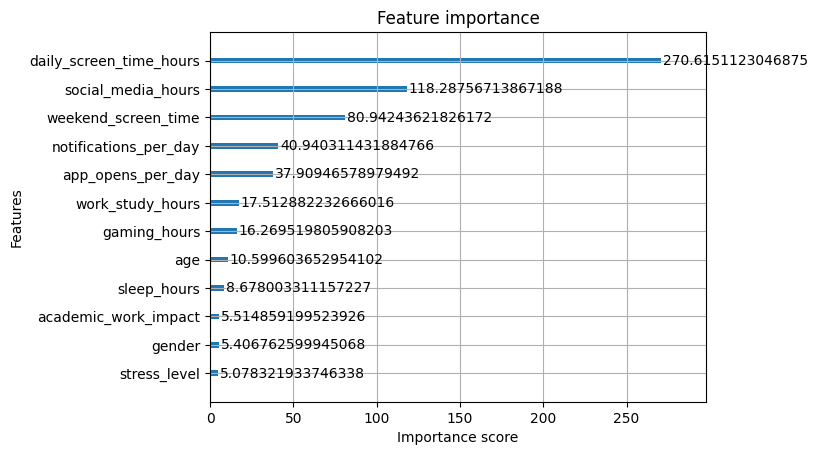

In [36]:
xgb.plot_importance(final_xgb_model, importance_type = 'gain')

Correlation

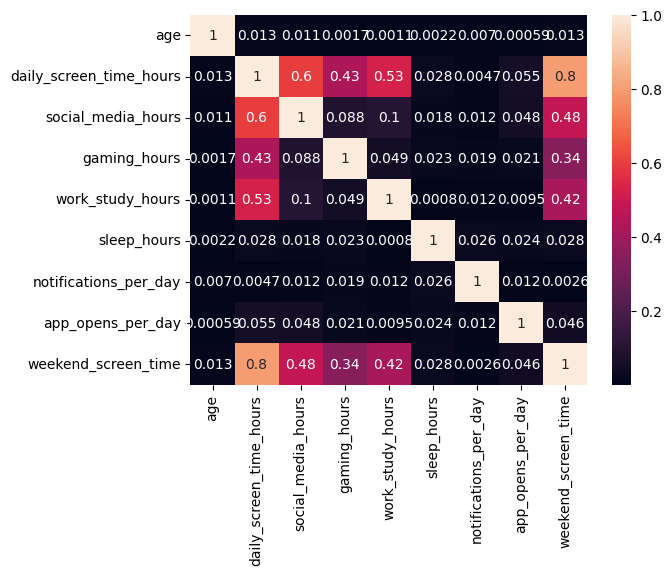

In [37]:
corr_matrix = x_train.corr(numeric_only = True).abs()
sns.heatmap(corr_matrix, annot = True)
plt.show()

SHAP values

In [38]:
import shap
explainer = shap.TreeExplainer(final_xgb_model)
shap_vals = explainer.shap_values(test)

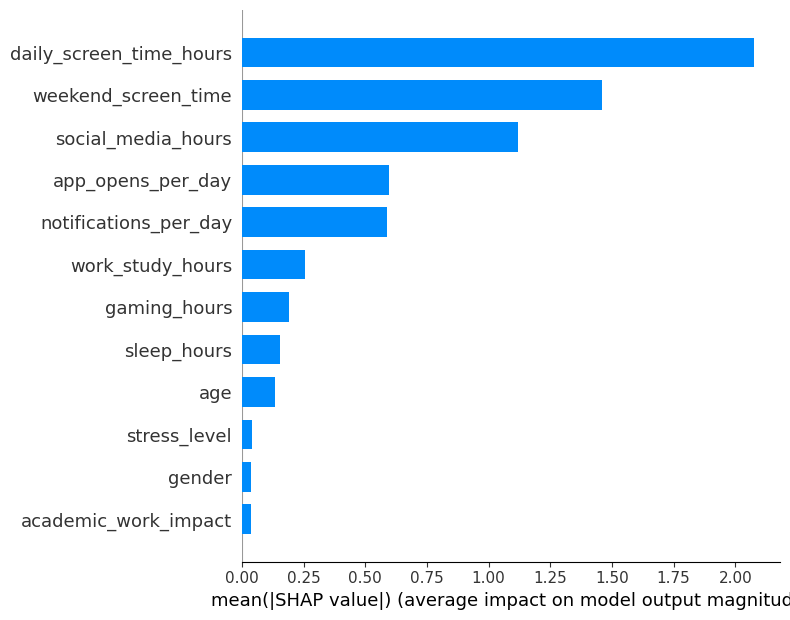

In [39]:
shap.summary_plot(shap_vals, test, plot_type = 'bar')